<a href="https://colab.research.google.com/github/aditya-03-githere/deep-learning-practice/blob/main/ANN/ANN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
df = pd.read_csv('Churn_Modelling.csv')

In [66]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [67]:
df.shape

(10000, 14)

In [68]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [71]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [72]:
df = df.drop(['RowNumber','CustomerId','Surname'],axis=1)

In [73]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [74]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

ohe_pipeline = Pipeline(steps=[
    ('ohe_encoder',OneHotEncoder())
])

scaler_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers = [
        ('ohe',ohe_pipeline,['Geography','Gender']),
        ('scale',scaler_pipeline,['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary'])
    ]
)

In [75]:
X = df.drop('Exited',axis=1)
y = df['Exited']

In [76]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [77]:
X_train

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
8371,813,Germany,Female,29,5,106059.40,1,0,0,187976.88
5027,681,Germany,Male,37,8,73179.34,2,1,1,25292.53
9234,642,Germany,Male,49,4,120688.61,1,1,0,24770.22
3944,612,France,Female,31,8,117989.76,1,1,1,54129.86
6862,586,France,Male,33,9,0.00,1,1,0,6975.02
...,...,...,...,...,...,...,...,...,...,...
5734,768,France,Male,54,8,69712.74,1,1,1,69381.05
5191,682,France,Female,58,1,0.00,1,1,1,706.50
5390,735,France,Female,38,1,0.00,3,0,0,92220.12
860,667,France,Male,43,8,190227.46,1,1,0,97508.04


In [78]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [79]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(64,activation='relu',input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

history = model.fit(X_train,y_train,epochs=50,batch_size=32,validation_split=0.2,callbacks=early_stopping)

Epoch 1/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7550 - loss: 0.5471 - val_accuracy: 0.7978 - val_loss: 0.4571
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7918 - loss: 0.4877 - val_accuracy: 0.7978 - val_loss: 0.4362
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7888 - loss: 0.4724 - val_accuracy: 0.8000 - val_loss: 0.4264
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7963 - loss: 0.4588 - val_accuracy: 0.8104 - val_loss: 0.4143
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8035 - loss: 0.4438 - val_accuracy: 0.8194 - val_loss: 0.4013
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8103 - loss: 0.4256 - val_accuracy: 0.8246 - val_loss: 0.3885
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8110 - loss: 0.4180 - val_accuracy: 0.8313 - val_loss: 0.3798
Epoch 8/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8134 - loss: 0.4213 - val_accuracy: 0

In [80]:
best_train_accuracy = max(history.history['accuracy'])
print("Best Training Accuracy:", best_train_accuracy)

Best Training Accuracy: 0.8444029688835144


In [93]:
best_val_accuracy = max(history.history['val_accuracy'])
print(f"Best Validation Accuracy: {best_val_accuracy}")

Best Validation Accuracy: 0.8537313342094421


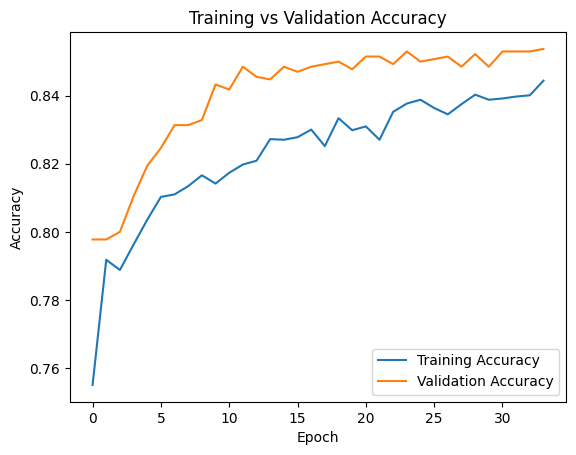

In [82]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

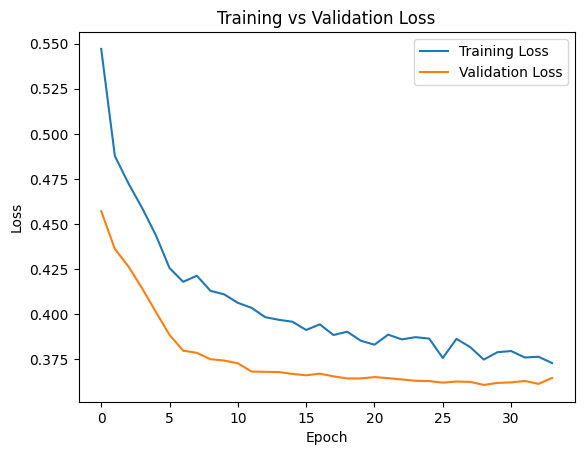

In [83]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [94]:
test_loss, test_accuracy = model.evaluate(X_test,y_test)

print(f"Test Accuracy: {test_accuracy}")
print(f"Test Loss: {test_loss}")

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8564 - loss: 0.3500
Test Accuracy: 0.8563636541366577
Test Loss: 0.3499963879585266


In [85]:
y_pred_prob = model.predict(X_test)

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [86]:
y_pred = (y_pred_prob > 0.3).astype(int)

In [87]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.85      0.88      2657
           1       0.53      0.69      0.60       643

    accuracy                           0.82      3300
   macro avg       0.72      0.77      0.74      3300
weighted avg       0.84      0.82      0.83      3300



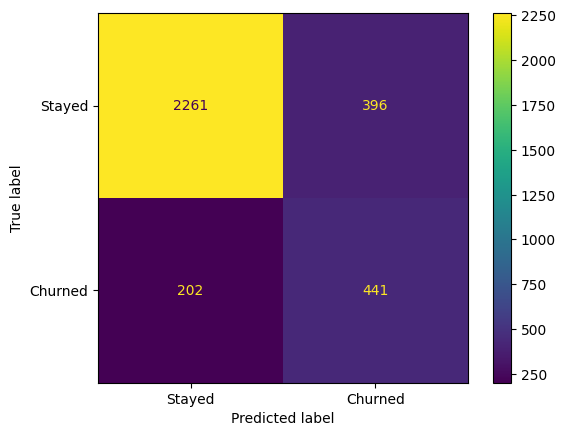

In [88]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Churned']
)

disp.plot()

In [89]:
y_pred_prob = model.predict(X_test).ravel()

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [90]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.8477094163075206


In [91]:
for threshold in [0.3, 0.4, 0.5, 0.6]:
    y_pred = (y_pred_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.92      0.85      0.88      2657
           1       0.53      0.69      0.60       643

    accuracy                           0.82      3300
   macro avg       0.72      0.77      0.74      3300
weighted avg       0.84      0.82      0.83      3300


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      2657
           1       0.65      0.54      0.59       643

    accuracy                           0.85      3300
   macro avg       0.77      0.73      0.75      3300
weighted avg       0.85      0.85      0.85      3300


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      2657
           1       0.72      0.43      0.54       643

    accuracy                           0.86      3300
   macro avg       0.80      0.69      0.73      3300
weighted avg       0.84   

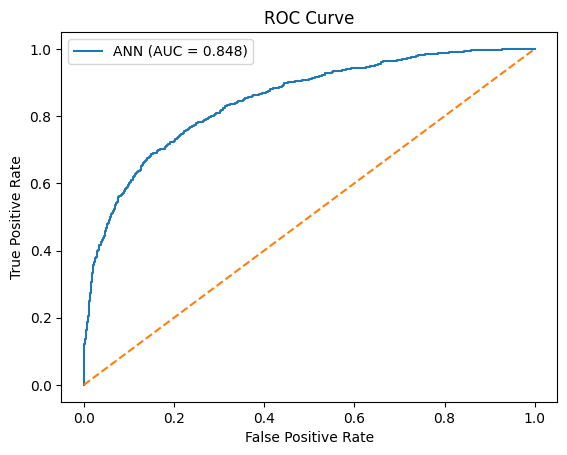

In [92]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

plt.plot(fpr, tpr, label=f'ANN (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()